# 01 — Data Exploration

SuperLender dataset. This notebook produces the figures needed for Chapter 3.

**Cell order matters.** Every engineered feature (age, region, interest margin) is
created *before* the train/validation/test split, so that the split sees the final
feature set. Do not move the split cell earlier.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA = '../project/'

perf = pd.read_csv(DATA + 'trainperf.csv')
demo = pd.read_csv(DATA + 'traindemographics.csv')
prev = pd.read_csv(DATA + 'trainprevloans.csv')

print('trainperf         ', perf.shape)
print('traindemographics ', demo.shape)
print('trainprevloans    ', prev.shape)

trainperf          (4368, 10)
traindemographics  (4346, 9)
trainprevloans     (18183, 12)


## 1. Table 3.1 — structure of each file

Confirms the record counts and the unit of observation.

In [2]:
for name, df_ in [('trainperf', perf), ('traindemographics', demo), ('trainprevloans', prev)]:
    print(f'--- {name} ---')
    print('rows:', len(df_), '| unique customerid:', df_['customerid'].nunique())
    print('columns:', list(df_.columns))
    print()

--- trainperf ---
rows: 4368 | unique customerid: 4368
columns: ['customerid', 'systemloanid', 'loannumber', 'approveddate', 'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby', 'good_bad_flag']

--- traindemographics ---
rows: 4346 | unique customerid: 4334
columns: ['customerid', 'birthdate', 'bank_account_type', 'longitude_gps', 'latitude_gps', 'bank_name_clients', 'bank_branch_clients', 'employment_status_clients', 'level_of_education_clients']

--- trainprevloans ---
rows: 18183 | unique customerid: 4359
columns: ['customerid', 'systemloanid', 'loannumber', 'approveddate', 'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate', 'referredby', 'firstduedate', 'firstrepaiddate']



In [3]:
perf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good


In [4]:
demo.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


In [5]:
prev.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


## 2. Section 3.3 — target distribution

Gives the default rate and the good:bad ratio.

In [6]:
counts = perf['good_bad_flag'].value_counts()
print(counts)
print()
print(perf['good_bad_flag'].value_counts(normalize=True).round(4))
print()

n_bad = counts.get('Bad', 0)
n_good = counts.get('Good', 0)
print(f'Bad loans      : {n_bad}')
print(f'Good loans     : {n_good}')
print(f'Default rate   : {n_bad / len(perf):.2%}')
print(f'Good:Bad ratio : {n_good / n_bad:.2f} : 1')

good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64

good_bad_flag
Good    0.7821
Bad     0.2179
Name: proportion, dtype: float64

Bad loans      : 952
Good loans     : 3416
Default rate   : 21.79%
Good:Bad ratio : 3.59 : 1


## 3. Section 3.5.1 — merge and match rate

How many loans have no demographic record.

In [7]:
# check demographics really is one row per customer
dupes = demo['customerid'].duplicated().sum()
print('duplicate customerid in demographics:', dupes)

demo_u = demo.drop_duplicates(subset='customerid', keep='first')

df = perf.merge(demo_u, on='customerid', how='left', indicator=True)
print()
print(df['_merge'].value_counts())

n_missing_demo = (df['_merge'] == 'left_only').sum()
print(f'\nLoans with no demographic record: {n_missing_demo} ({n_missing_demo / len(df):.2%})')

df['has_demographics'] = (df['_merge'] == 'both').astype(int)
df = df.drop(columns='_merge')

duplicate customerid in demographics: 12

_merge
both          3269
left_only     1099
right_only       0
Name: count, dtype: int64

Loans with no demographic record: 1099 (25.16%)


## 4. Section 3.5.2 — missing values (Table 3.2)

In [8]:
miss = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
miss = miss[miss > 0]
print('Missing values by column (%):')
print(miss.to_string())

Missing values by column (%):
bank_branch_clients           99.24
level_of_education_clients    89.86
referredby                    86.56
employment_status_clients     36.45
longitude_gps                 25.16
latitude_gps                  25.16
birthdate                     25.16
bank_account_type             25.16
bank_name_clients             25.16


## 5. Section 3.5.3 — data quality checks

Three checks are reported in the chapter: implausible ages, GPS points outside
Nigeria, and duplicate loan identifiers.

Note: the GPS bounding box below is a **sanity check only**. The figure quoted in
the chapter (36 records) comes from the point-in-polygon join in Section 3.6.2,
which uses Nigeria's actual borders rather than a rectangle. A point can sit
inside this box and still fall outside the country.

In [9]:
# parse dates once, here — later cells depend on these being datetimes
for c in ['approveddate', 'creationdate']:
    df[c] = pd.to_datetime(df[c], errors='coerce')
    try:
        df[c] = df[c].dt.tz_localize(None)
    except (TypeError, AttributeError):
        pass

df['birthdate'] = pd.to_datetime(df['birthdate'], errors='coerce')
try:
    df['birthdate'] = df['birthdate'].dt.tz_localize(None)
except (TypeError, AttributeError):
    pass

print('approveddate dtype:', df['approveddate'].dtype)
print('birthdate    dtype:', df['birthdate'].dtype)

approveddate dtype: datetime64[ns]
birthdate    dtype: datetime64[ns]


In [10]:
# GPS sanity check: Nigeria is roughly lat 4-14 N, lon 2.5-15 E
gps = df[['latitude_gps', 'longitude_gps']].dropna()
print(gps.describe().round(3))

outside_box = (
    (df['latitude_gps'] < 4) | (df['latitude_gps'] > 14) |
    (df['longitude_gps'] < 2.5) | (df['longitude_gps'] > 15)
)
print(f'\nGPS points outside bounding box: {outside_box.sum()}  (sanity check only)')
print(f'GPS missing entirely           : {df["latitude_gps"].isna().sum()}')

       latitude_gps  longitude_gps
count      3269.000       3269.000
mean          7.290          4.531
std           3.270          7.925
min         -33.869       -118.247
25%           6.474          3.355
50%           6.626          3.584
75%           7.427          6.440
max          71.228        151.209

GPS points outside bounding box: 31  (sanity check only)
GPS missing entirely           : 1099


In [11]:
# duplicate loans
print('duplicate systemloanid:', perf['systemloanid'].duplicated().sum())
print('\nloans per customer:')
print(perf['customerid'].value_counts().value_counts().sort_index().to_string())
print('\nOne loan per customer -> a random split cannot leak a customer across sets.')

duplicate systemloanid: 0

loans per customer:
count
1    4368

One loan per customer -> a random split cannot leak a customer across sets.


## 6. Section 3.6.2 — age at approval

Age is computed at the date the loan was approved, not at the date of analysis.
The continuous variable `age_at_approval` is a model input; the banded
`age_band` is used only to report fairness results.

In [12]:
df['age_at_approval'] = (df['approveddate'] - df['birthdate']).dt.days / 365.25

print(df['age_at_approval'].describe().round(1))

implausible = df['age_at_approval'].notna() & ((df['age_at_approval'] < 18) | (df['age_at_approval'] > 80))
print(f'\nImplausible ages (<18 or >80): {implausible.sum()}')
df.loc[implausible, 'age_at_approval'] = pd.NA

count    3269.0
mean       32.9
std         6.1
min        21.3
25%        28.5
50%        32.2
75%        36.6
max        55.7
Name: age_at_approval, dtype: float64

Implausible ages (<18 or >80): 0


In [13]:
# Age bands for the fairness audit.
# 35-44 and 45+ are merged: 45+ holds only ~28 loans in the test set, too few
# for a stable rate. Same minimum-group-size rule applied to region below.
df['age_band'] = pd.cut(
    df['age_at_approval'].astype('float'),
    bins=[18, 25, 35, 45, 80],
    labels=['18-24', '25-34', '35-44', '45+'],
    right=False,
).astype('object').fillna('Unknown')

df['age_band'] = df['age_band'].replace({'45+': '35+', '35-44': '35+'})
print(df['age_band'].value_counts().to_string())

age_band
25-34      1941
Unknown    1099
35+        1064
18-24       264


## 7. Section 3.6.2 — geographic region from GPS coordinates

Each coordinate is matched to a Nigerian state by a point-in-polygon spatial join
against GADM v4.1 boundaries, then states are grouped into the six geopolitical
zones. `region` (six zones) is the model input; `region_fair` (five groups, with
the three sparse zones merged) is used to report fairness results.

In [14]:
# %pip install geopandas
import geopandas as gpd
import re

# 1. State boundaries (GADM v4.1, level 1 = 36 states + FCT)
states = gpd.read_file("gadm41_NGA_1.json")[["NAME_1", "geometry"]]

# 2. States -> six geopolitical zones
zones = {
    "North Central": ["Benue", "Kogi", "Kwara", "Nasarawa", "Niger", "Plateau", "Federal Capital Territory"],
    "North East":    ["Adamawa", "Bauchi", "Borno", "Gombe", "Taraba", "Yobe"],
    "North West":    ["Jigawa", "Kaduna", "Kano", "Katsina", "Kebbi", "Sokoto", "Zamfara"],
    "South East":    ["Abia", "Anambra", "Ebonyi", "Enugu", "Imo"],
    "South South":   ["Akwa Ibom", "Bayelsa", "Cross River", "Delta", "Edo", "Rivers"],
    "South West":    ["Ekiti", "Lagos", "Ogun", "Ondo", "Osun", "Oyo"],
}
norm = lambda s: re.sub(r"[^a-z]", "", s.lower()).replace("nassarawa", "nasarawa")
state_to_zone = {norm(s): z for z, lst in zones.items() for s in lst}

states["zone"] = states["NAME_1"].map(lambda s: state_to_zone.get(norm(s)))
assert states["zone"].notna().all(), states.loc[states["zone"].isna(), "NAME_1"].tolist()

# 3. Point-in-polygon join (only rows that have coordinates)
has_gps = df["longitude_gps"].notna() & df["latitude_gps"].notna()
pts = gpd.GeoDataFrame(
    df.loc[has_gps, []],
    geometry=gpd.points_from_xy(df.loc[has_gps, "longitude_gps"],
                                df.loc[has_gps, "latitude_gps"]),
    crs="EPSG:4326",
).to_crs(states.crs)

joined = gpd.sjoin(pts, states[["NAME_1", "zone", "geometry"]],
                   how="left", predicate="within")
joined = joined[~joined.index.duplicated(keep="first")]   # points on a border

df["state"]  = joined["NAME_1"].reindex(df.index)
df["region"] = joined["zone"].reindex(df.index).fillna("Unknown")

# 4. Numbers to report in the text
no_gps    = (~has_gps).sum()
unmatched = (has_gps & df["state"].isna()).sum()
print(f"No coordinates           : {no_gps} ({no_gps/len(df):.2%})")
print(f"Coordinates outside NG   : {unmatched} ({unmatched/len(df):.2%})")
print()
print(df["region"].value_counts().to_string())

No coordinates           : 1099 (25.16%)
Coordinates outside NG   : 36 (0.82%)

region
South West       2145
Unknown          1135
North Central     511
South South       366
North West         98
South East         93
North East         20


In [15]:
# Collapse sparse zones for the fairness audit.
# North East (20), South East (93) and North West (98) are too small to support
# a reliable rate once the test split is taken.
SMALL_ZONES = ["North West", "South East", "North East"]
df["region_fair"] = df["region"].replace({z: "Other regions" for z in SMALL_ZONES})

print(df["region_fair"].value_counts().to_string())

region_fair
South West       2145
Unknown          1135
North Central     511
South South       366
Other regions     211


## 8. Section 3.6.3 — interest margin

In [16]:
df['interest_margin'] = (df['totaldue'] - df['loanamount']) / df['loanamount']

print(df['interest_margin'].describe().round(4))
print()

m_median = df['interest_margin'].median()
m_mean = df['interest_margin'].mean()
print(f'Median margin : {m_median:.4f}')
print(f'Mean margin   : {m_mean:.4f}')

count    4368.0000
mean        0.2177
std         0.0771
min         0.0000
25%         0.1500
50%         0.2250
75%         0.3000
max         0.3000
Name: interest_margin, dtype: float64

Median margin : 0.2250
Mean margin   : 0.2177


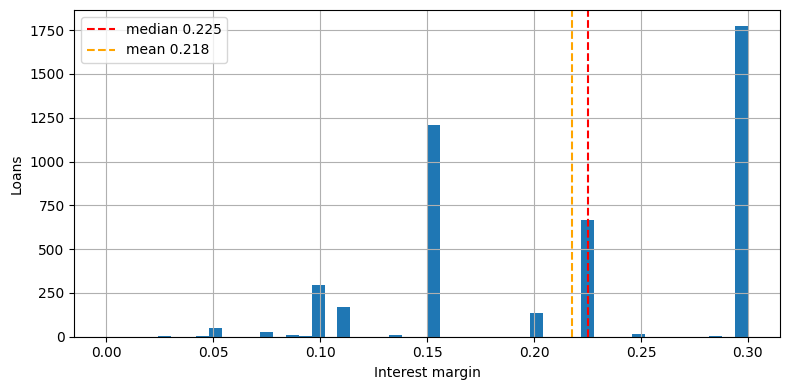

In [17]:
# distribution of margins — check whether median vs mean matters
fig, ax = plt.subplots(figsize=(8, 4))
df['interest_margin'].hist(bins=50, ax=ax)
ax.axvline(m_median, color='red', linestyle='--', label=f'median {m_median:.3f}')
ax.axvline(m_mean, color='orange', linestyle='--', label=f'mean {m_mean:.3f}')
ax.set_xlabel('Interest margin')
ax.set_ylabel('Loans')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Section 3.8.3 — the cost-derived threshold p*

Elkan's threshold: p* = m / (m + LGD).

In [18]:
print('Sensitivity analysis (Section 3.8.4), using the median margin:')
print(f'{"LGD":>6} | {"p*":>8}')
print('-' * 18)
for lgd in [0.25, 0.50, 0.75, 1.00]:
    p_star = m_median / (m_median + lgd)
    print(f'{lgd:>6.2f} | {p_star:>8.4f}')

Sensitivity analysis (Section 3.8.4), using the median margin:
   LGD |       p*
------------------
  0.25 |   0.4737
  0.50 |   0.3103
  0.75 |   0.2308
  1.00 |   0.1837


## 10. Section 3.9.1 — date range, for the split decision

In [19]:
print('First approval:', df['approveddate'].min())
print('Last approval :', df['approveddate'].max())
print('Span (days)   :', (df['approveddate'].max() - df['approveddate'].min()).days)
print()

# default rate over time — is there a trend that would justify a temporal split?
tmp = df.copy()
tmp['month'] = tmp['approveddate'].dt.to_period('M')
tmp['is_bad'] = (tmp['good_bad_flag'] == 'Bad').astype(int)
monthly = tmp.groupby('month').agg(loans=('is_bad', 'size'), bad_rate=('is_bad', 'mean'))
print(monthly.round(3).to_string())

First approval: 2017-07-01 01:35:26
Last approval : 2017-07-30 22:55:51
Span (days)   : 29

         loans  bad_rate
month                   
2017-07   4368     0.218


## 11. Section 3.6.1 — prior loans, and the leakage check

In [20]:
for c in ['approveddate', 'firstduedate', 'firstrepaiddate']:
    prev[c] = pd.to_datetime(prev[c], errors='coerce')
    try:
        prev[c] = prev[c].dt.tz_localize(None)
    except (TypeError, AttributeError):
        pass

prev['days_late'] = (prev['firstrepaiddate'] - prev['firstduedate']).dt.days
prev['was_late'] = (prev['days_late'] > 0).astype(int)

print('Prior loans per customer:')
print(prev['customerid'].value_counts().describe().round(1))
print()
print('Late rate across all prior loans:', round(prev['was_late'].mean(), 4))
print()
print(prev['days_late'].describe().round(1))

Prior loans per customer:
count    4359.0
mean        4.2
std         3.7
min         1.0
25%         1.0
50%         3.0
75%         6.0
max        26.0
Name: count, dtype: float64

Late rate across all prior loans: 0.1738

count    18183.0
mean        -2.5
std          9.9
min        -32.0
25%         -6.0
50%         -2.0
75%          0.0
max        351.0
Name: days_late, dtype: float64


In [21]:
# LEAKAGE CHECK: how many prior loans were approved AFTER the current loan?
# Those must be excluded from the aggregation in notebook 02.
chk = prev[['customerid', 'approveddate']].merge(
    df[['customerid', 'approveddate']].rename(columns={'approveddate': 'current_approved'}),
    on='customerid', how='inner'
)

after = (chk['approveddate'] >= chk['current_approved']).sum()
print(f'Prior-loan rows dated on or after the current loan: {after} of {len(chk)}')
print('These must be filtered out when building features.')

Prior-loan rows dated on or after the current loan: 0 of 18183
These must be filtered out when building features.


In [22]:
# how many current-loan customers have no prior loans at all?
no_history = ~df['customerid'].isin(prev['customerid'])
print(f'Customers with no prior loans: {no_history.sum()} ({no_history.mean():.2%})')

Customers with no prior loans: 9 (0.21%)


## 12. Section 3.5.4 — train / validation / test split

**This cell runs last.** Every engineered feature must already exist in `df`,
otherwise the split silently produces a feature set that is missing them. The
assertion below is the guard against that.

In [23]:
from sklearn.model_selection import train_test_split

TARGET = "good_bad_flag"
SEED   = 42

# Columns that must not be model inputs:
#   identifiers, raw dates already turned into features,
#   raw GPS (superseded by region), and the two audit-only variables.
drop_cols = [TARGET, "customerid", "systemloanid", "loannumber",
             "approveddate", "creationdate", "birthdate",
             "longitude_gps", "latitude_gps", "state",
             "region_fair", "age_band"]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = (df[TARGET] == "Bad").astype(int)      # 1 = default

# Guard: fail loudly if a feature cell was skipped or run out of order
required = ["age_at_approval", "interest_margin", "region",
            "has_demographics", "loanamount", "termdays"]
missing = [c for c in required if c not in X.columns]
assert not missing, f"Missing features — re-run the cells above: {missing}"

# 60 / 20 / 20, stratified so the default rate is equal in all three sets
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

for name, yy in [("Train", y_tr), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<11} n = {len(yy):>5}   default rate = {yy.mean():.4f}")

print(f"\nFeatures passed to the models ({len(X.columns)}):")
print(sorted(X.columns.tolist()))

Train       n =  2620   default rate = 0.2179
Validation  n =   874   default rate = 0.2185
Test        n =   874   default rate = 0.2174

Features passed to the models (13):
['age_at_approval', 'bank_account_type', 'bank_branch_clients', 'bank_name_clients', 'employment_status_clients', 'has_demographics', 'interest_margin', 'level_of_education_clients', 'loanamount', 'referredby', 'region', 'termdays', 'totaldue']


In [24]:
# Protected-attribute group sizes in the test set — these are the group
# sizes the fairness audit in Chapter 4 can actually support.
print('region_fair (test set)')
print(df.loc[X_test.index, 'region_fair'].value_counts().to_string())
print()
print('age_band (test set)')
print(df.loc[X_test.index, 'age_band'].value_counts().to_string())

region_fair (test set)
region_fair
South West       434
Unknown          233
North Central     92
South South       77
Other regions     38

age_band (test set)
age_band
25-34      387
Unknown    228
35+        218
18-24       41


## 13. Summary of values for Chapter 3

Copy these into the draft.

In [25]:
print('=' * 58)
print('VALUES FOR CHAPTER 3')
print('=' * 58)
print(f'3.3  trainperf rows              : {len(perf)}')
print(f'3.3  traindemographics rows      : {len(demo)}')
print(f'3.3  trainprevloans rows         : {len(prev)}')
print(f'3.3  bad loans                   : {n_bad}')
print(f'3.3  default rate                : {n_bad / len(perf):.2%}')
print(f'3.7  good:bad ratio              : {n_good / n_bad:.2f} : 1')
print(f'3.5  loans without demographics  : {n_missing_demo}')
print(f'3.5  implausible ages            : {implausible.sum()}')
print(f'3.5  GPS outside Nigeria (GADM)  : {unmatched}')
print(f'3.6  customers with no history   : {no_history.sum()}')
print(f'3.6  age range                   : {df["age_at_approval"].min():.1f} to {df["age_at_approval"].max():.1f}')
print(f'3.8  median interest margin      : {m_median:.4f}')
print(f'3.8  mean interest margin        : {m_mean:.4f}')
print(f'3.8  p* at LGD = 1.0             : {m_median / (m_median + 1):.4f}')
print(f'3.9  date range                  : {df["approveddate"].min().date()} to {df["approveddate"].max().date()}')
print(f'3.5  train / val / test          : {len(y_tr)} / {len(y_val)} / {len(y_test)}')
print('=' * 58)

VALUES FOR CHAPTER 3
3.3  trainperf rows              : 4368
3.3  traindemographics rows      : 4346
3.3  trainprevloans rows         : 18183
3.3  bad loans                   : 952
3.3  default rate                : 21.79%
3.7  good:bad ratio              : 3.59 : 1
3.5  loans without demographics  : 1099
3.5  implausible ages            : 0
3.5  GPS outside Nigeria (GADM)  : 36
3.6  customers with no history   : 9
3.6  age range                   : 21.3 to 55.7
3.8  median interest margin      : 0.2250
3.8  mean interest margin        : 0.2177
3.8  p* at LGD = 1.0             : 0.1837
3.9  date range                  : 2017-07-01 to 2017-07-30
3.5  train / val / test          : 2620 / 874 / 874


In [3]:
%pip install xgboost lightgbm catboost optuna fairlearn

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
